## 0. CARGA DE DATOS Y VISTAZO GENERAL

In [ ]:
# instalar via pip en un venv
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# estas ya vienen por defecto con python
import ssl
import requests
import io


# Tarda 2 minutos en cargar aprox.
response = requests.get(
    'https://datosabiertos.jcyl.es/web/jcyl/risp/es/medio-ambiente/calidad_aire_historico/1284212629698.csv',
    verify=False  # desactivamos verificacion SSL
)
calidad_aire = pd.read_csv(io.StringIO(response.text), sep=';')



# Mostrar las primeras filas del DataFrame
print("*** HEAD ***")
#
print("="*100)

# Mostrar la estructura del DataFrame
print("*** INFO ***")
#
print("="*100)
# Mostrar un resumen estadístico de las variables numéricas
print("*** DESC ***")
#
print("="*100)

In [ ]:
calidad_aire.head

## 1. DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS

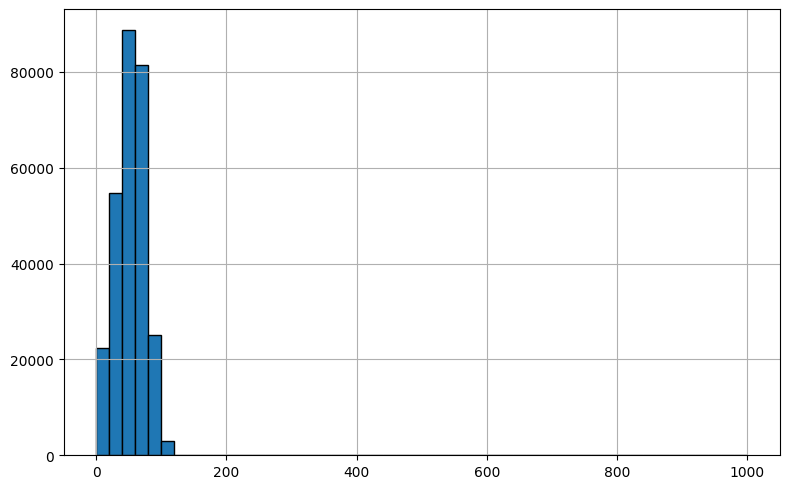

In [ ]:
# 1_1
# CREA ESTE HISTOGRAMA PARA O3 (ug/m3)

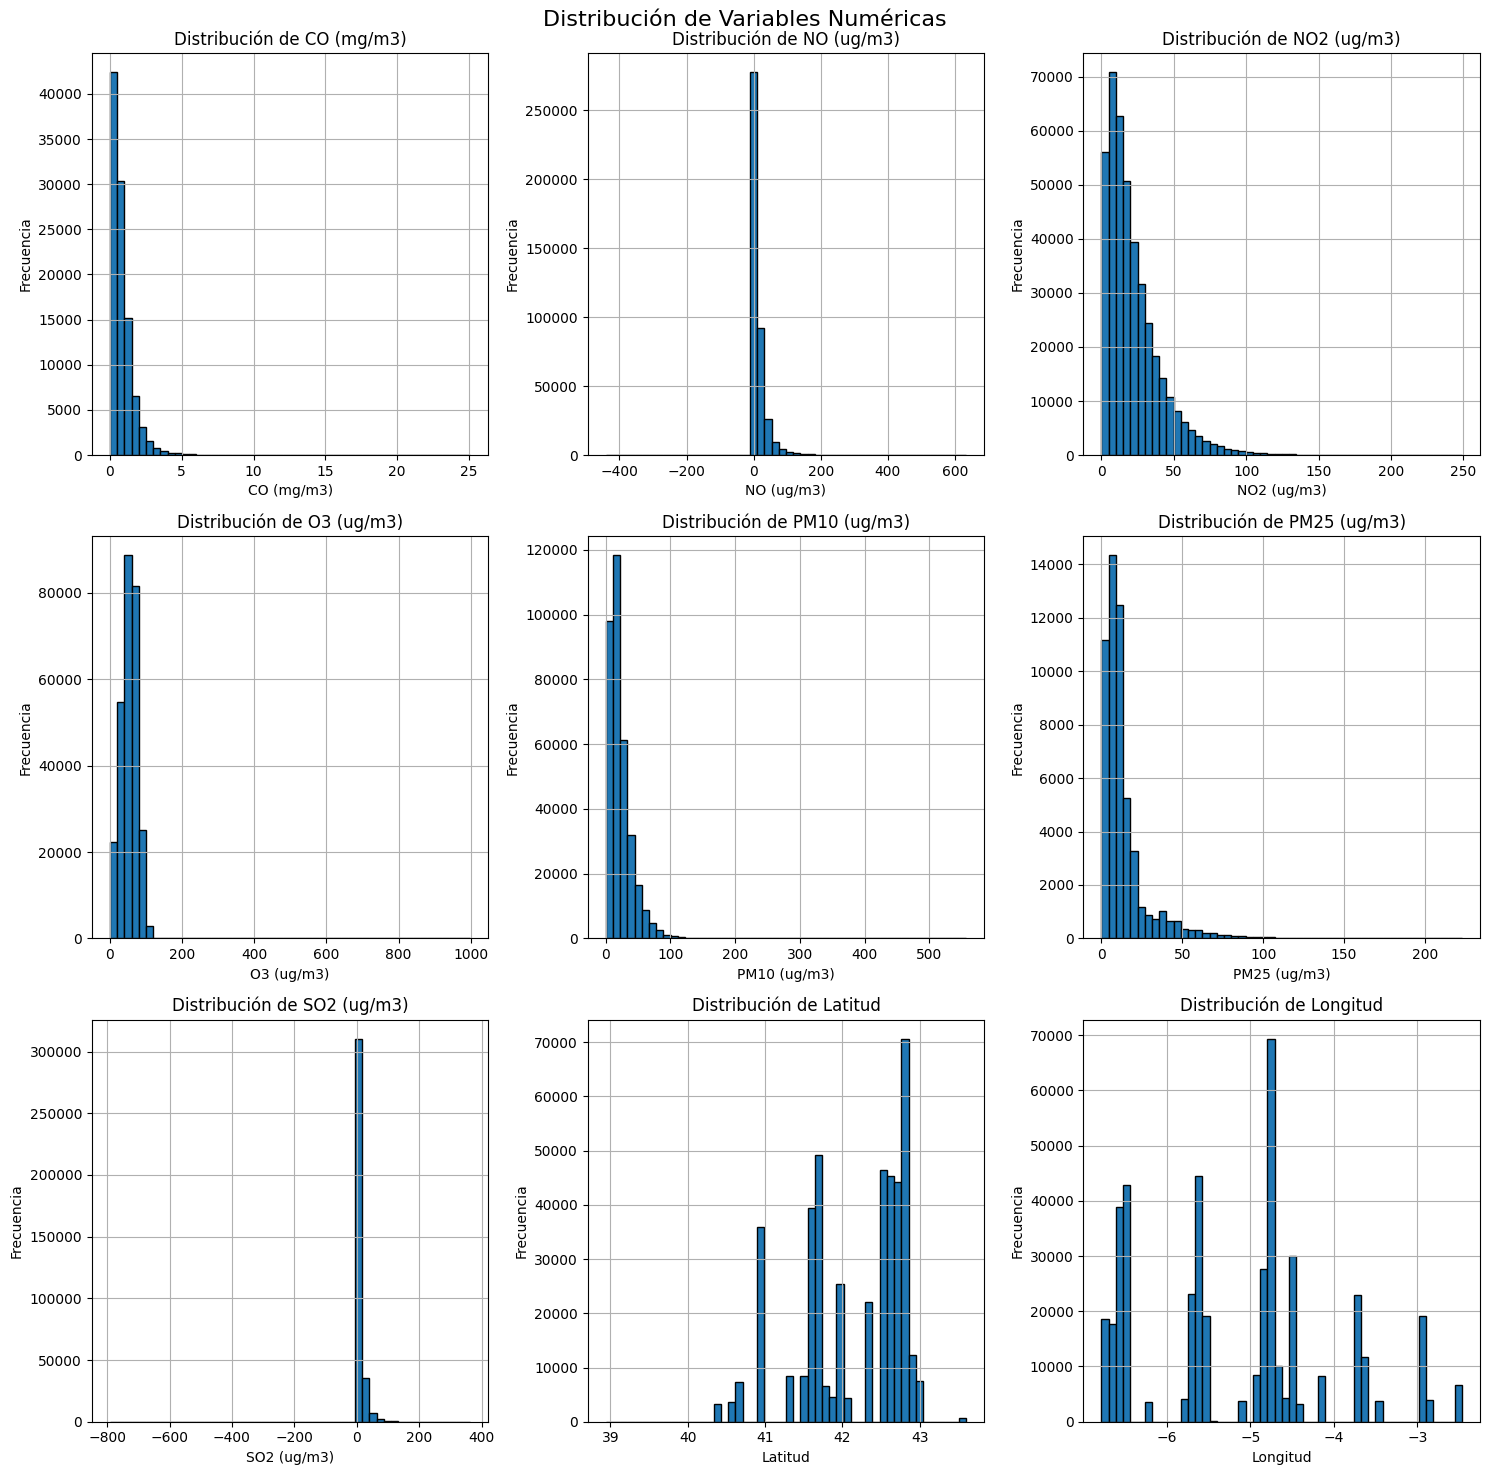

In [ ]:
# 1_2
#  Seleccionar solo las columnas numéricas
columnas_numericas = calidad_aire.select_dtypes(include=[np.number]).columns

# Calcular el número de filas y columnas para el subplot
n = len(columnas_numericas)
nrows = 3
ncols = min(n, 3)

# Crear la figura y los subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Aplanar el array de ejes en caso de que sea 2D
axes = axes.flatten() if n > 3 else [axes]

# Crear histogramas para cada variable numérica
for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    calidad_aire[col].hist(ax=ax, bins=50, edgecolor='black')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

# Ocultar subplots vacíos si los hay
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 2. AJUSTE DE LAS VARIABLES CATEGÓRICAS

In [ ]:
# 2_1
# Ajustar el tipo de la variable Fecha

# Ajustar el tipo de la variable Provincia

# Ajustar el tipo de la variable Estación


## 3. ANÁLISIS DE DATOS AUSENTES

In [ ]:
# 3_1
print()

In [ ]:
# 3_2

## TRATAMIENTO DE DATOS AUSENTES (ELIMINACIÓN E IMPUTACIÓN POR LA MEDIA)

In [ ]:
# 3_3
# Guardar dataset original
calidad_aire_original = calidad_aire.copy()

# Eliminación de las variables que presentan un % de NaN superior al 50%

print(f" Tras esta operación, contamos con {len(calidad_aire.columns)} columnas")




In [ ]:
# 3_4
# Seleccionamos las variables numéricas con una máscara booleana

# Calculamos la media para cada una de las variables numéricas sin tener en cuenta los NaN


# Sustituimos los valores NaN por la media correspondiente a cada variable

## 4. DETECCIÓN DE ATÍPICOS SOBRE VARIABLES NUMÉRICAS (HISTOGRAMA Y GRAFICO DE CAJAS Y BIGOTES)

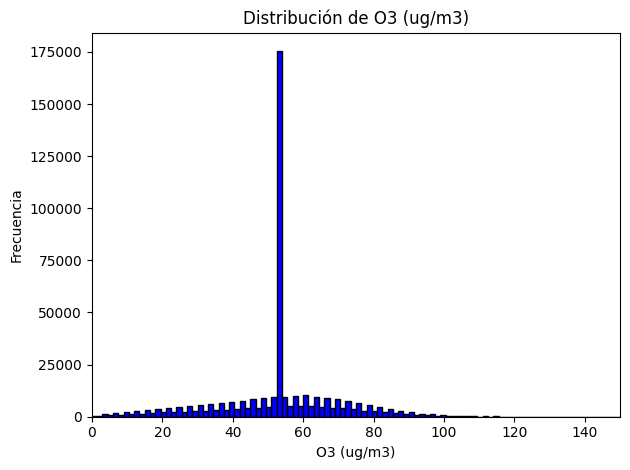

Estadísticas para O3:
Q1 - 1.5IQR = 31.50
Q1 = 48.00
Mediana = 52.62
Q3 = 59.00
Q3 + 1.5IQR = 75.50
Número de observaciones: 446014
Número de outliers: 91163


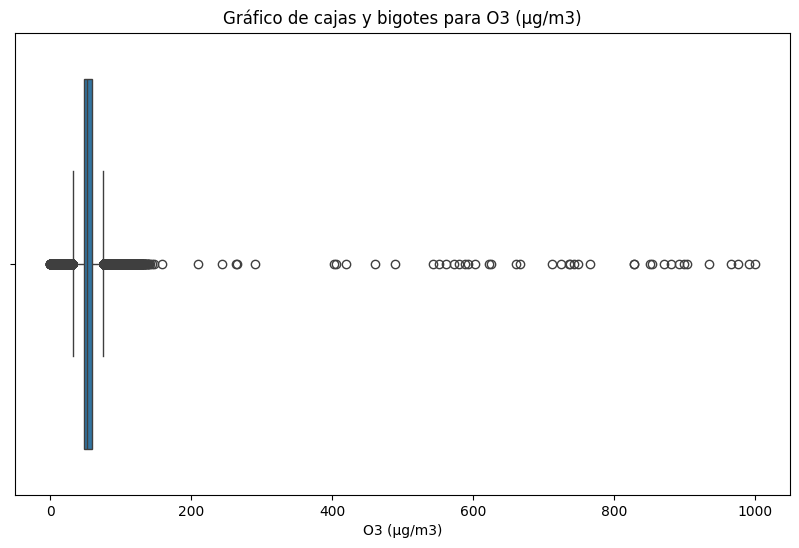

In [ ]:
# 4_1
plt.hist(calidad_aire['O3 (ug/m3)'], bins=100, range=(0, 150), color='blue', edgecolor='black')
plt.title('Distribución de O3 (ug/m3)')
plt.xlabel('O3 (ug/m3)')
plt.ylabel('Frecuencia')
plt.xlim(0,150)
plt.tight_layout()
plt.show()


# Estadísticas necesarias para reproducir el gráfico de cajas y bigotes
Q1 = calidad_aire['O3 (ug/m3)'].quantile(0.25)
Q3 = calidad_aire['O3 (ug/m3)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Estadísticas para O3:")
print(f"Q1 - 1.5IQR = {lower_bound:.2f}")
print(f"Q1 = {Q1:.2f}")
print(f"Mediana = {calidad_aire['O3 (ug/m3)'].median():.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"Q3 + 1.5IQR = {upper_bound:.2f}")
print(f"Número de observaciones: {len(calidad_aire['O3 (ug/m3)'])}")
print(f"Número de outliers: {sum((calidad_aire['O3 (ug/m3)'] < lower_bound) | (calidad_aire['O3 (ug/m3)'] > upper_bound))}")

# Construcción del gráfico de cajas y bigotes
plt.figure(figsize=(10, 6))
sns.boxplot(x=calidad_aire['O3 (ug/m3)'])
plt.title('Gráfico de cajas y bigotes para O3 (µg/m3)')
plt.xlabel('O3 (µg/m3)')
plt.show()


## DETECCIÓN DE ATÍPICOS SOBRE VARIABLES CATEGÓRICAS

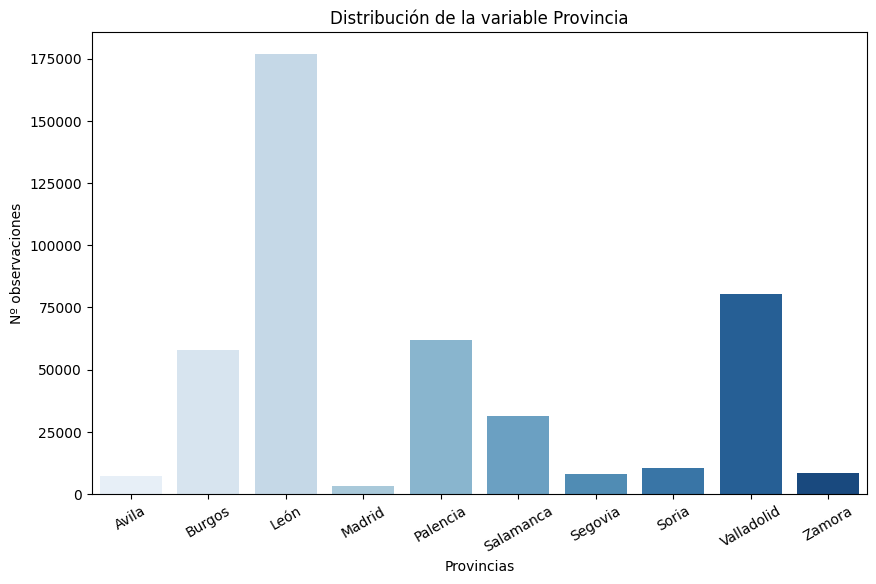

In [ ]:
# 4_2
# Número de categorías que presenta la variable Provincia
categoria_counts = calidad_aire['Provincia'].value_counts()

# Construcción del gráfico de barras para la variable Provincia
plt.figure(figsize=(10, 6))
sns.barplot(x=categoria_counts.index, y=categoria_counts.values, palette='Blues', hue=categoria_counts.index, legend=False)
plt.xlabel('Provincias')
plt.ylabel('Nº observaciones')
plt.xticks(rotation=30)
plt.title('Distribución de la variable Provincia')
plt.show()


## TRATAMIENTO DE VALORES ATÍPICOS EN VARIABLES NUMÉRICAS

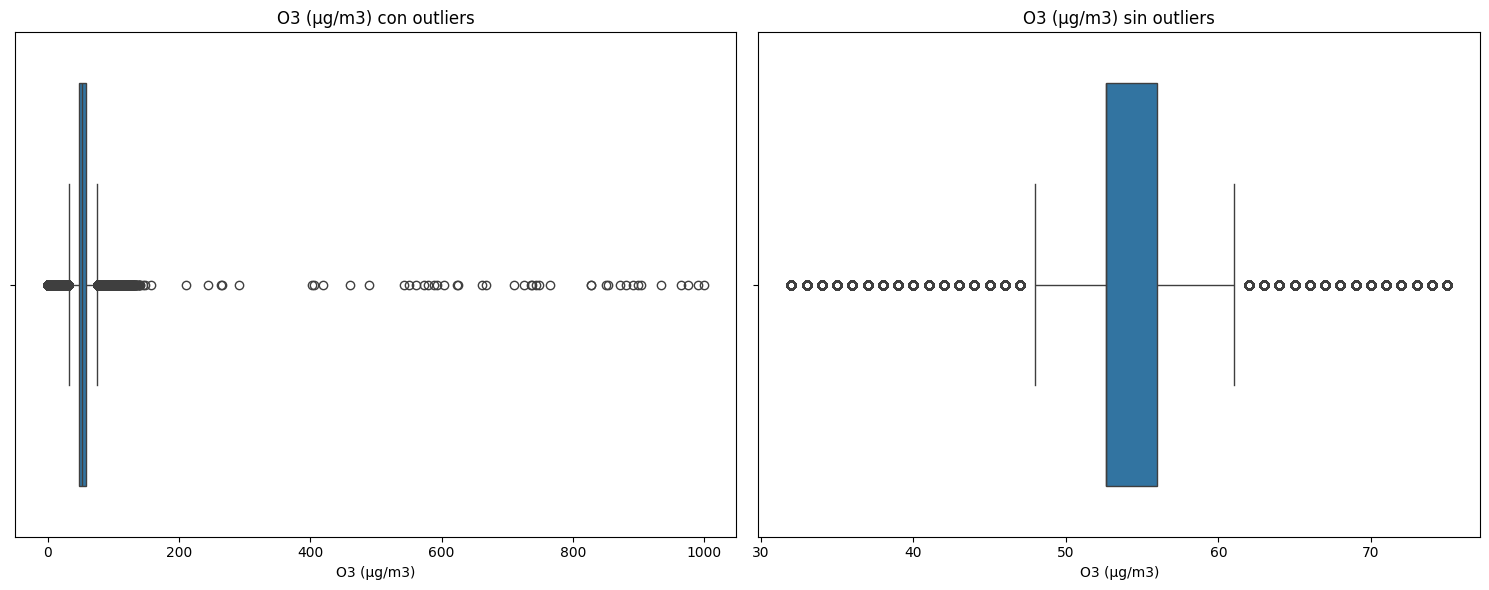

In [ ]:
# Se genera una nueva tabla que no contiene los valores identificados como atípicos

# Construcción de los gráficos de cajas y bigotes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x=calidad_aire['O3 (ug/m3)'], ax=ax1)
ax1.set_title('O3 (µg/m3) con outliers')
ax1.set_xlabel('O3 (µg/m3)')

sns.boxplot(x=calidad_aire_NoOut['O3 (ug/m3)'], ax=ax2)
ax2.set_title('O3 (µg/m3) sin outliers')
ax2.set_xlabel('O3 (µg/m3)')

plt.tight_layout()
plt.show()


## TRATAMIENTO DE VALORES ATÍPICOS EN VARIABLES CATEGÓRICAS

In [ ]:
# Creamos una copia explícita del DataFrame excluyendo las filas de Madrid

# Eliminamos las categorías no utilizadas
calidad_aire_SM['Provincia'] = calidad_aire_SM['Provincia'].astype('category').cat.remove_unused_categories()

# Verificamos la eliminación de la categoría "Madrid"
print(calidad_aire_SM['Provincia'].cat.categories)

## 5. ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES

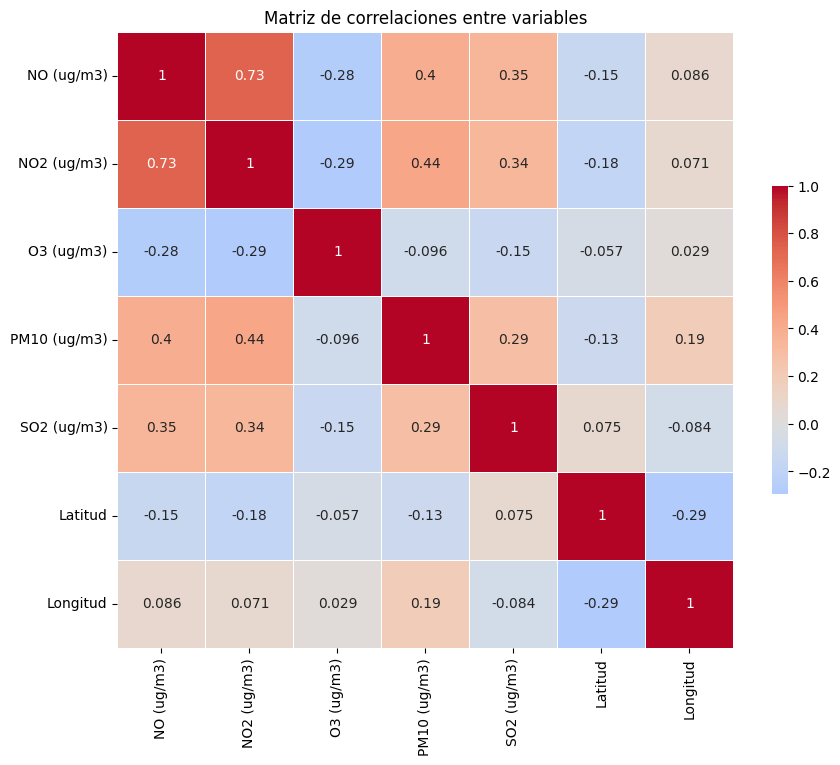

In [ ]:
#5_1

# Calculamos la matriz de coeficientes de correlación entre las variables numéricas


# Configuración del gráfico de correlación
plt.figure(figsize=(10, 8))

# Gráfico de correlaciones utilizando un mapa de calor
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Matriz de correlaciones entre variables')
plt.show()


## EDA AUTOMÁTICO

In [ ]:
# FALTA